# Linear Regression

## Part 1: Linear Regression from Scratch

Predicting house prices from scratch:

1. Import Required Packages
2. Import Dataset
3. Visualize Data
4. Clean, Encode and Split Data
5. Normalize the data
6. Implement Functions: `compute_cost`, `compute_gradient`, `gradient_descent`, `predict`
7. Train the Model
8. Evaluate Results

### Step 1: Import Required Packages

- **pandas:** read the dataset from CSV format
- **numpy:** represent data as arrays for numerical computation
- **matplotlib:**  data visualization and plots
- **train_test_split:** used to split database into training and testing 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Step 2: Import Dataset

Import dataset (.csv format) using pandas
The data is imported from kaggle.com for [California House Prices](https://www.kaggle.com/datasets/shibumohapatra/house-price/data?select=1553768847-housing.csv).

In [3]:
df = pd.read_csv("data/raw/1553768847-housing.csv")

print(f"The data set is made of {df.shape[0]} rows and {df.shape[1]} columns")
df.head(5)

The data set is made of 20640 rows and 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


### Step 3: Visualize Data

Before training, it is good practice to explore the data visually to understand distribution, spot outliers, and see relationships between features and the target variable `median_house_value`

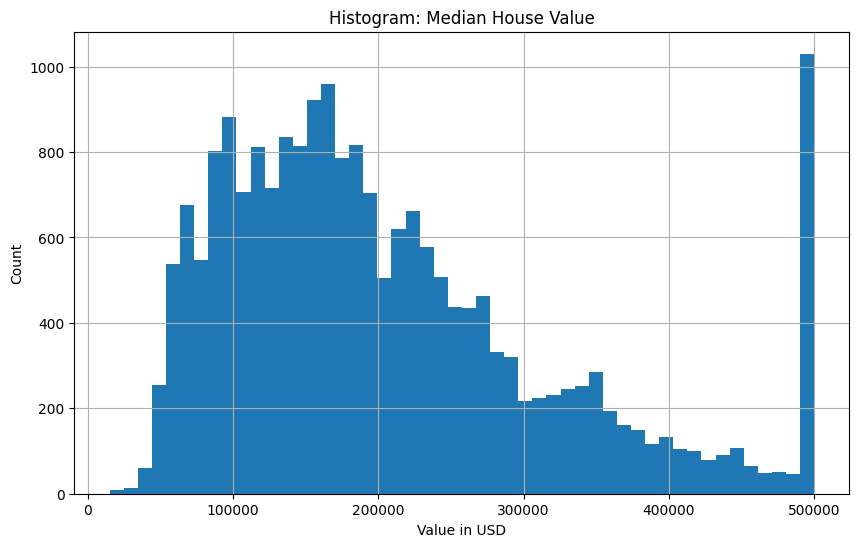

In [4]:
plt.figure(figsize=(10,6))
plt.hist(df["median_house_value"], bins=50)
plt.title("Histogram: Median House Value")
plt.xlabel("Value in USD")
plt.ylabel("Count")
plt.grid(True)
plt.show()

Below is a scatter plot for the median income against the median house value.

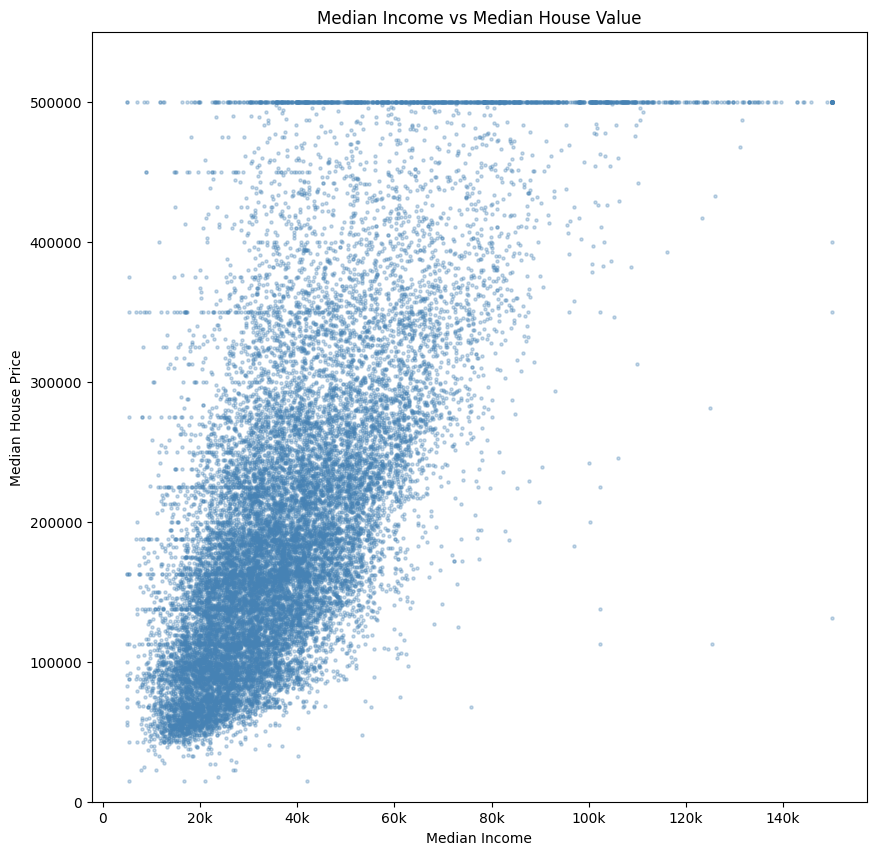

In [5]:
plt.figure(figsize=(10,10))
plt.scatter(df["median_income"], df["median_house_value"], alpha=0.3, s=5, color="steelblue")
plt.ylim(0, df["median_house_value"].max() * 1.1)
plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.xticks([0, 2, 4, 6, 8, 10, 12, 14], 
           ['0', '20k', '40k', '60k', '80k', '100k', '120k', '140k'])
plt.ylabel("Median House Price")
plt.show()

Each point on the plot represents a house, positioned by its geographic location (`longitude`, `latitude`), with color indicating its price.

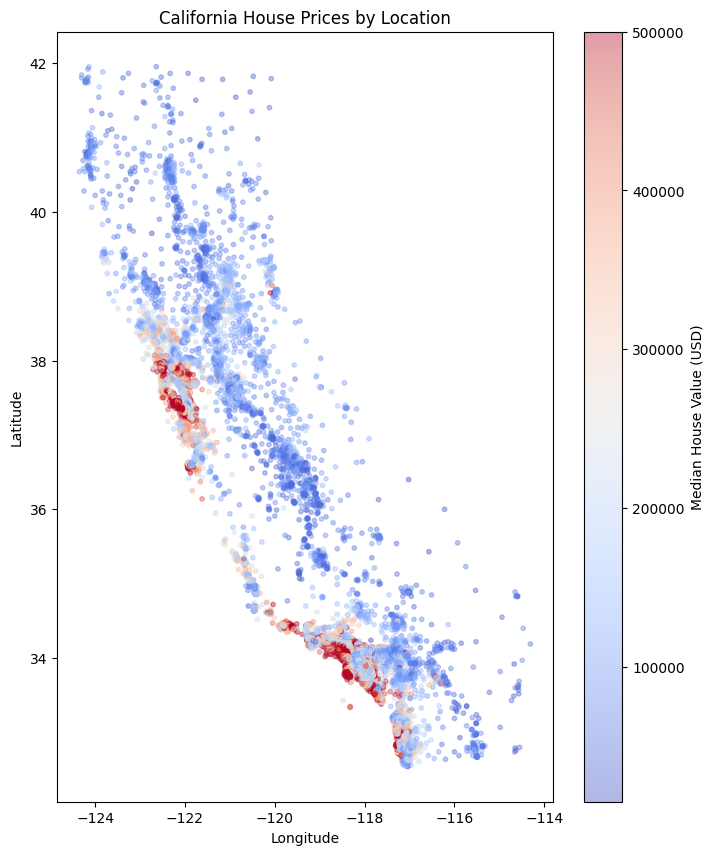

In [6]:
plt.figure(figsize=(8,10))
plt.scatter(df["longitude"], df["latitude"], c=df["median_house_value"], cmap='coolwarm', alpha=0.4, s=10)
plt.title("California House Prices by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Median House Value (USD)")
plt.show()

### Step 4: Clean, Encode and Split

In this step we check if the data is clean by handling missing values and improper data. We also encode categorical variables.

From the previous step it is clear that all features are numerical except `ocean_proximity`, which needs to be encoded before training.

In [7]:
print(f"This will summrize the missing values: {df.isnull().sum()}")
print(f"The unique variables of ocean proximity has {len(df["ocean_proximity"].unique())} which are {df["ocean_proximity"].unique()}")

This will summrize the missing values: longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64
The unique variables of ocean proximity has 5 which are <StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


We found that `total_bedrooms` has 207 missing values, so we will fill them with the median of that column.

In [8]:
# Replace NA of total_bedrooms with median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)

df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,0,0,0,1,0
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,0,0,0,1,0
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,0,0,0,1,0
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,0,0,0,1,0
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,0,0,0,1,0


Now we need to split the output randomly into training set and testing set. 

In [9]:
# select all features except the outcome
x = np.array(df.drop(columns=['median_house_value']))
# select the output 
y = np.array(df['median_house_value'])

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2
)


### Step 5: Normalize Data

Before training, we normalize the features to ensure all values are on the same scale, preventing larger values from dominating the model.

The code below will do the normalization manually through standarization (Z-score).

In [ ]:
# this to store mean and std 
mean_std = {}

# Loop over each numerical column in X_train (all 13 features)
for i in range(13):
    mean = X_train[:,i].mean()
    std = X_train[:,i].std()
    mean_std[i] = (mean, std)
    X_train[:,i] = (X_train[:,i] - mean) / std
    
# Normalize the test set using mean and std from the training set
for i in range(13):
    mean, std = mean_std[i]
    X_test[:,i] = (X_test[:,i] - mean) / std
    
y_train = y_train / 100000
y_test = y_test / 100000

Now data is normalized and ready for training and testing. 

### Step 6: Implement Functions

- `compute_cost` calculate the MSE loss
- `compute_gradient` calculate the gradient for each iteration
- `gradient_descent` iterate and update weights and bias, and report the cost
- `predict` apply final weights to make predictions

Cost will be calcualted using this equation:


$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

In [14]:
print(X_train.shape
      )

(16512, 13)


In [21]:
def compute_cost(X, y, w, b):
    # m is the number of training examples
    m = X.shape[0]    
    total_cost = 0.0

    # loop through all the rows 
    # for i in range(m):
    #     cost = np.dot(X[i], w) + b - y[i]
    #     cost = cost**2
    #     total_cost = total_cost + cost 
    # return total_cost / (2 * m)
    
    # better to implemnt using matrix multipliacation 
    # above loop loop is making the function slow
    error = np.matmul(X, w) + b - y
    total_cost = np.sum(error ** 2) / (2 * m)
    return total_cost

`compute_gradient` will be an implementation of the following equations:

$$\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) x^{(i)}$$

$$\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})$$

In [22]:
def compute_gradient(X, y, w, b):
    # m is the number of rows
    # n is the number of features 
    m,n = X.shape
    
    # np.array of all the values 
    dj_dw = np.zeros(n)
    dj_db = 0
    
    # for i in range(m):
    #     err = np.dot(X[i], w) + b - y[i]
    #     dj_dw_tm = err * X[i]
    #     dj_db_tm = err
    #     dj_dw += dj_dw_tm
    #     dj_db += dj_db_tm
    # dj_dw = dj_dw / m
    # dj_db = dj_db / m
    
    # same as compute_cost better to do matrix multiplication
    err = np.matmul(X, w) + b - y
    dj_dw = np.matmul(X.T, err) / m
    dj_db = np.sum(err)/m
    
    return dj_dw, dj_db

`gradient_descent`, this functions is going to:
- input:
  - X: features
  - y: output
  - w: weights
  - b: bias
  - alpha: laerning_rate
  - num_of_iter: number of the iterations
  - cost_function: log the cost with iterations
  - gradient_function: calcute the gradient for each step

- output:
  - w_out: updated w vector after training
  - b_out: updated b adter training

Gradient descent applies this fucntion: 

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$

In [23]:
def gradient_descent(X, y, w, b, alpha, num_of_iter, cost_function, gradient_function):
    # cost_history = []
    
    w_out = w
    b_out = b
    
    for i in range(num_of_iter):
        dj_dw, dj_db = gradient_function(X, y, w, b)
        w_out = w_out - alpha * dj_dw
        b_out = b_out - alpha * dj_db
        
        # # store cost per iteration
        # cost_history.append(cost_function(X, y, w_out, b_out))
        
        if i % 1000 == 0:
            print(f"Iteration {i}: Cost = {cost_function(X, y, w_out, b_out)}")
        
    return w_out, b_out

`predict` takes `w` and `b`, then predicts the the output.
- input:
  - w: optimized weights from the training
  - b: optimized bias for training
  - X_testing: take the normlalized X_testing
- output:
  - yhat: return the predicted values  

In [31]:
def predict(w, b, X_testing):
    m = X_testing.shape[0]
    
    yhat = np.zeros(m)
    
    for i in range(m):
        yhat[i] = np.dot(X_testing[i], w) + b
    return yhat

### Step 7: Train the Model

We initialize the weights to zero and train the model using gradient descent.
The model will iteratively update the weights and bias to minimize the cost function.

In [48]:
# initial w and b to zeros
w = np.zeros(13)
b = 0
alpha = 0.00005# learning rate 
num_of_iter = 20000

w, b = gradient_descent(X_train, y_train, w, b, alpha, num_of_iter, compute_cost, compute_gradient)

Iteration 0: Cost = 2.807776891736026
Iteration 1000: Cost = 2.5423146408259916
Iteration 2000: Cost = 2.292354149053011
Iteration 3000: Cost = 2.0578954164170735
Iteration 4000: Cost = 1.8389384429181752
Iteration 5000: Cost = 1.6354832285563246
Iteration 6000: Cost = 1.4475297733315216
Iteration 7000: Cost = 1.2750780772437718
Iteration 8000: Cost = 1.1181281402930676
Iteration 9000: Cost = 0.9766799624794056
Iteration 10000: Cost = 0.8507335438027854
Iteration 11000: Cost = 0.74028888426321
Iteration 12000: Cost = 0.6453459838606798
Iteration 13000: Cost = 0.5659048425951947
Iteration 14000: Cost = 0.5019654604667549
Iteration 15000: Cost = 0.4535278374753603
Iteration 16000: Cost = 0.4205919736210075
Iteration 17000: Cost = 0.40315786890369903
Iteration 18000: Cost = 0.40122552332344436
Iteration 19000: Cost = 0.41479493688023605


### Step 8: Evaluate the Results 

- get the predicted value given the w and b from training
- calcualte mse and R2

In [49]:
y_hat = predict(w, b, X_test)

# scale back up 
# y_hat  = y_hat   *   100000
# y_test = y_test * 100000

# Mean Square error
mse = np.mean((y_test - y_hat) ** 2)
rmse = np.sqrt(mse)

# R2
ss_res = np.sum((y_test - y_hat) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"Mean Squared Error is {mse}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 is {r2}")

Mean Squared Error is 0.9061207242723425
RMSE: 0.95
R2 is 0.33317222127585167


Mean Squared Error is 8692552451.667841
RMSE: 93233.86
R2 is 0.3436460263779154

## Part 2: Linear Regression with Scikit-learn

In this part, we implement the same linear regression model using scikit-learn 
and compare the results with our scratch implementation from Part 1.

1. Import `LinearRegression` from scikit-learn
2. Train the model on `X_train` and `y_train`
3. Predict on `X_test`
4. Evaluate using MSE and R²
5. Compare results with Part 1

In [50]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train / 100000)
y_pred = lr_model.predict(X_test)

print("R2 on test set:", lr_model.score(X_test, y_test / 100000))

R2 on test set: 0.6330208498026642
